# Survey Properties: Redshift Distributions

This notebook analyzes the redshift distributions for:
1. Galaxies in tomographic bins
2. Galaxy types (early-type and late-type)
3. Clusters

## Setup and Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from pathlib import Path

# Set plot style to match clustering analysis
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 15
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['xtick.minor.size'] = 4
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['ytick.minor.size'] = 4
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['axes.linewidth'] = 1.5

# Colors matching clustering analysis
COLOR_EARLY = '#e81010'  # Red for early-type
COLOR_LATE = '#008fd6'   # Blue for late-type
COLOR_ALL = 'black'      # Black for all galaxies
COLOR_CLUSTERS = 'purple'  # Purple for clusters

# Paths to data
CLUSTER_CATALOG = '/sps/euclid/Users/cmurray/RR2_alt/amico_merged_cl2025-07-17T09_36_11.fits'
GALAXY_CATALOG = '/sps/euclid/Users/cmurray/rr2_data/galaxies.fits'

# Tomographic redshift bins (matching clustering analysis)
REDSHIFT_BINS = [0.1, 0.4, 0.7, 1.0, 1.3, 1.6, 1.9]

# Output directory
OUTPUT_DIR = Path('survey_properties_plots')
OUTPUT_DIR.mkdir(exist_ok=True)

print("Configuration loaded!")

Configuration loaded!


## Load Catalogues

In [2]:
# Load cluster catalogue
print("Loading cluster catalogue...")
clusters = Table.read(CLUSTER_CATALOG)
cluster_z = clusters['Z_CLUSTER']
print(f"  Loaded {len(clusters)} clusters")
print(f"  Redshift range: {cluster_z.min():.3f} - {cluster_z.max():.3f}")

# Load galaxy catalogue
print("\nLoading galaxy catalogue...")
galaxies = Table.read(GALAXY_CATALOG)
galaxy_z = galaxies['phz_median']
galaxy_sersic = galaxies['sersic_sersic_vis_index']
print(f"  Loaded {len(galaxies)} galaxies")
print(f"  Redshift range: {galaxy_z.min():.3f} - {galaxy_z.max():.3f}")

# Split galaxies by type
mask_early = galaxy_sersic >= 2.0
mask_late = galaxy_sersic < 2.0

galaxy_z_early = galaxy_z[mask_early]
galaxy_z_late = galaxy_z[mask_late]

print(f"\nGalaxy type split:")
print(f"  Early-type (n ≥ 2.0): {len(galaxy_z_early)} ({100*len(galaxy_z_early)/len(galaxies):.1f}%)")
print(f"  Late-type (n < 2.0): {len(galaxy_z_late)} ({100*len(galaxy_z_late)/len(galaxies):.1f}%)")

Loading cluster catalogue...
  Loaded 25843 clusters
  Redshift range: 0.050 - 2.400

Loading galaxy catalogue...
  Loaded 62343553 galaxies
  Redshift range: 0.010 - 6.000

Galaxy type split:
  Early-type (n ≥ 2.0): 17429571 (28.0%)
  Late-type (n < 2.0): 44913982 (72.0%)


## Plot 1: Galaxy n(z) in Tomographic Bins

In [8]:
bin_edges

array([0.  , 0.04, 0.08, 0.12, 0.16, 0.2 , 0.24, 0.28, 0.32, 0.36, 0.4 ,
       0.44, 0.48, 0.52, 0.56, 0.6 , 0.64, 0.68, 0.72, 0.76, 0.8 , 0.84,
       0.88, 0.92, 0.96, 1.  , 1.04, 1.08, 1.12, 1.16, 1.2 , 1.24, 1.28,
       1.32, 1.36, 1.4 , 1.44, 1.48, 1.52, 1.56, 1.6 , 1.64, 1.68, 1.72,
       1.76, 1.8 , 1.84, 1.88, 1.92, 1.96, 2.  ])

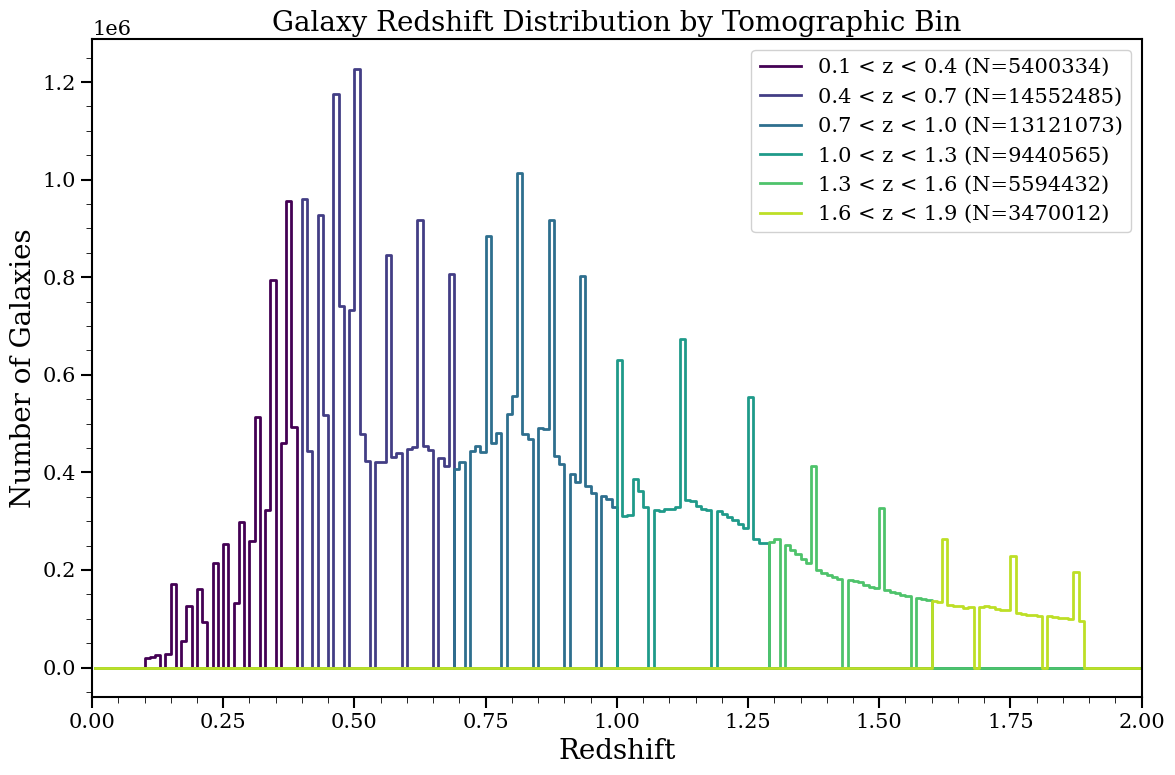

Saved: survey_properties_plots/nz_galaxies_tomographic.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create histogram for each tomographic bin
z_range = (0.0, 2.0)
n_bins = 200
bin_edges = np.linspace(z_range[0], z_range[1], n_bins + 1)

# Colors for tomographic bins
colors = plt.cm.viridis(np.linspace(0, 0.9, len(REDSHIFT_BINS) - 1))

for i in range(len(REDSHIFT_BINS) - 1):
    z_min, z_max = REDSHIFT_BINS[i], REDSHIFT_BINS[i + 1]
    
    # Select galaxies in this bin
    mask = (galaxy_z >= z_min) & (galaxy_z < z_max)
    z_in_bin = galaxy_z[mask]
    
    # Create histogram
    counts, _ = np.histogram(z_in_bin, bins=bin_edges)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    
    # Plot with steps-mid style for histogram appearance
    ax.plot(bin_centers, counts, color=colors[i], linewidth=2, 
            drawstyle='steps-mid',
            label=f'{z_min:.1f} < z < {z_max:.1f} (N={len(z_in_bin)})')

ax.set_xlabel('Redshift')
ax.set_ylabel('Number of Galaxies')
ax.set_title('Galaxy Redshift Distribution by Tomographic Bin')
ax.legend(loc='upper right', frameon=True, framealpha=0.9)
ax.minorticks_on()
ax.set_xlim(z_range)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'nz_galaxies_tomographic.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {OUTPUT_DIR / 'nz_galaxies_tomographic.png'}")

## Plot 2: Galaxy n(z) by Type (Early vs Late)

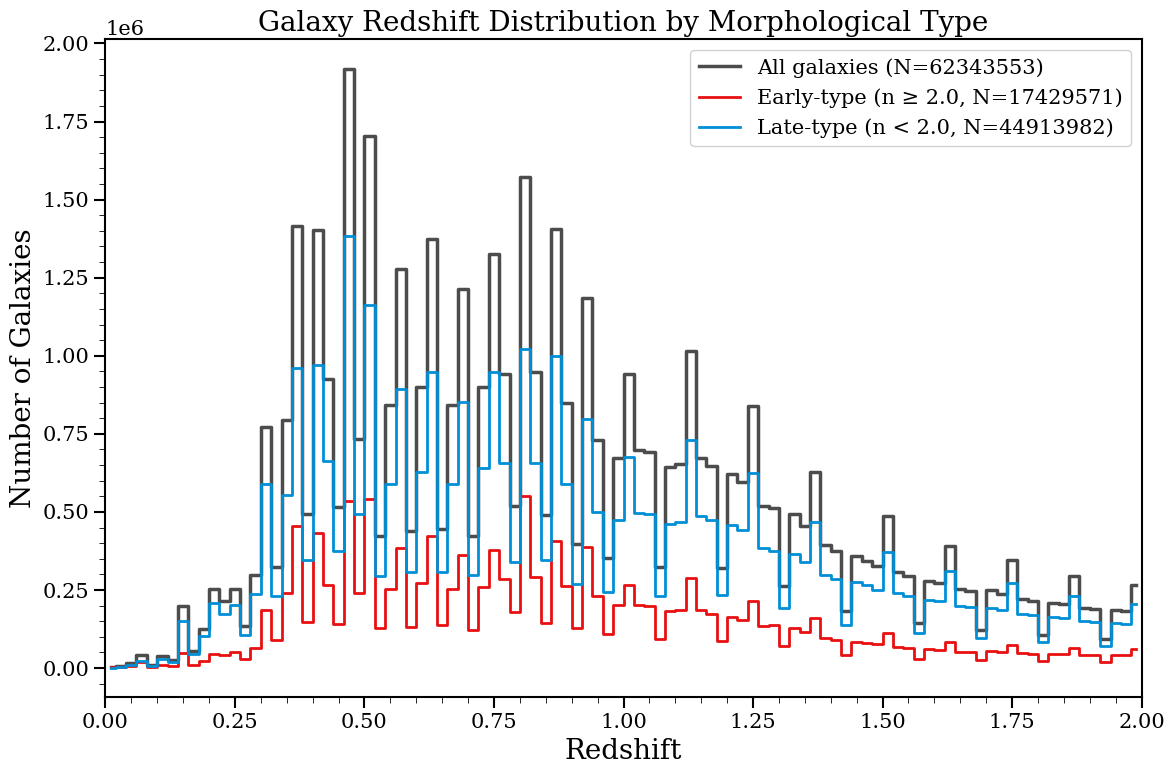

Saved: survey_properties_plots/nz_galaxies_by_type.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 8))

# Histogram settings
z_range = (0.0, 2.0)
n_bins = 100
bin_edges = np.linspace(z_range[0], z_range[1], n_bins + 1)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# All galaxies
counts_all, _ = np.histogram(galaxy_z, bins=bin_edges)
ax.plot(bin_centers, counts_all, color=COLOR_ALL, linewidth=2.5,
        drawstyle='steps-mid',
        label=f'All galaxies (N={len(galaxy_z)})', alpha=0.7)

# Early-type galaxies
counts_early, _ = np.histogram(galaxy_z_early, bins=bin_edges)
ax.plot(bin_centers, counts_early, color=COLOR_EARLY, linewidth=2,
        drawstyle='steps-mid',
        label=f'Early-type (n ≥ 2.0, N={len(galaxy_z_early)})')

# Late-type galaxies
counts_late, _ = np.histogram(galaxy_z_late, bins=bin_edges)
ax.plot(bin_centers, counts_late, color=COLOR_LATE, linewidth=2,
        drawstyle='steps-mid',
        label=f'Late-type (n < 2.0, N={len(galaxy_z_late)})')

ax.set_xlabel('Redshift')
ax.set_ylabel('Number of Galaxies')
ax.set_title('Galaxy Redshift Distribution by Morphological Type')
ax.legend(loc='upper right', frameon=True, framealpha=0.9)
ax.minorticks_on()
ax.set_xlim(z_range)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'nz_galaxies_by_type.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {OUTPUT_DIR / 'nz_galaxies_by_type.png'}")

## Plot 3: Cluster n(z)

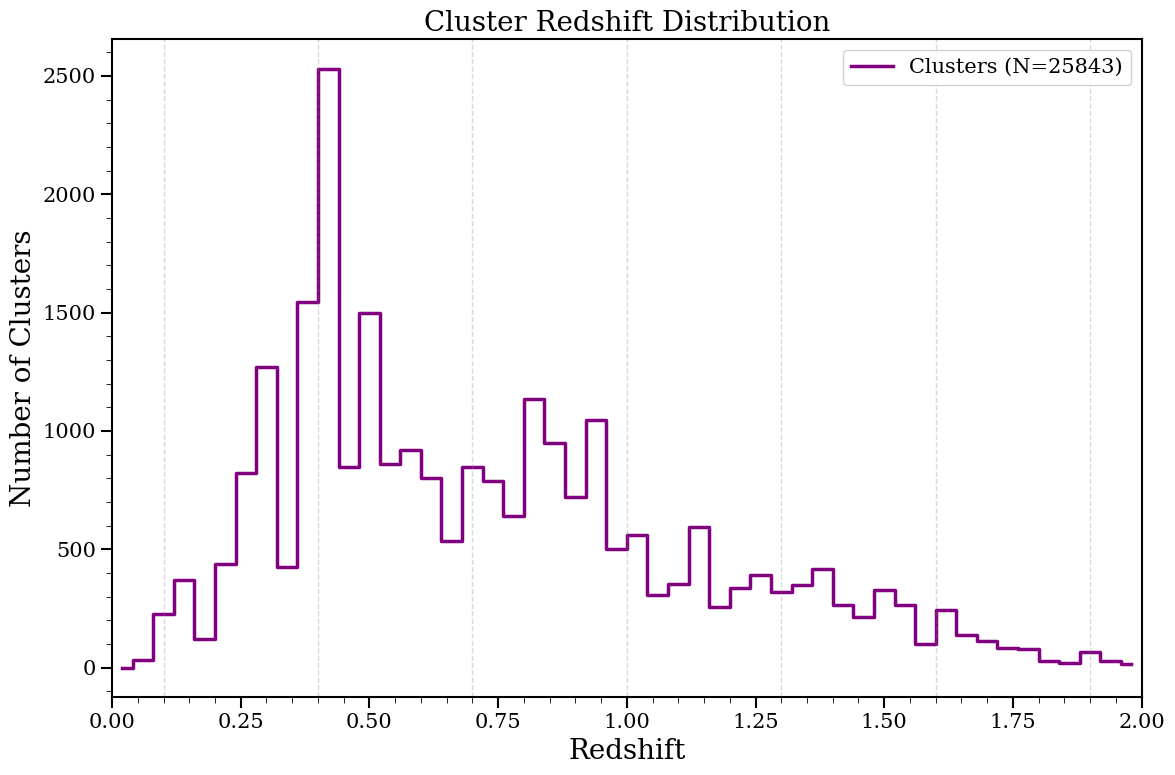

Saved: survey_properties_plots/nz_clusters.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 8))

# Histogram settings
z_range = (0.0, 2.0)
n_bins = 50  # Fewer bins for clusters since there are fewer of them
bin_edges = np.linspace(z_range[0], z_range[1], n_bins + 1)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# Cluster histogram
counts_clusters, _ = np.histogram(cluster_z, bins=bin_edges)
ax.plot(bin_centers, counts_clusters, color=COLOR_CLUSTERS, linewidth=2.5,
        drawstyle='steps-mid',
        label=f'Clusters (N={len(cluster_z)})')

# Add vertical lines for tomographic bin edges
for z_edge in REDSHIFT_BINS:
    ax.axvline(z_edge, color='gray', linestyle='--', alpha=0.3, linewidth=1)

ax.set_xlabel('Redshift')
ax.set_ylabel('Number of Clusters')
ax.set_title('Cluster Redshift Distribution')
ax.legend(loc='upper right', frameon=True, framealpha=0.9)
ax.minorticks_on()
ax.set_xlim(z_range)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'nz_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {OUTPUT_DIR / 'nz_clusters.png'}")

## Plot 4: Combined Overview (All on One Plot)

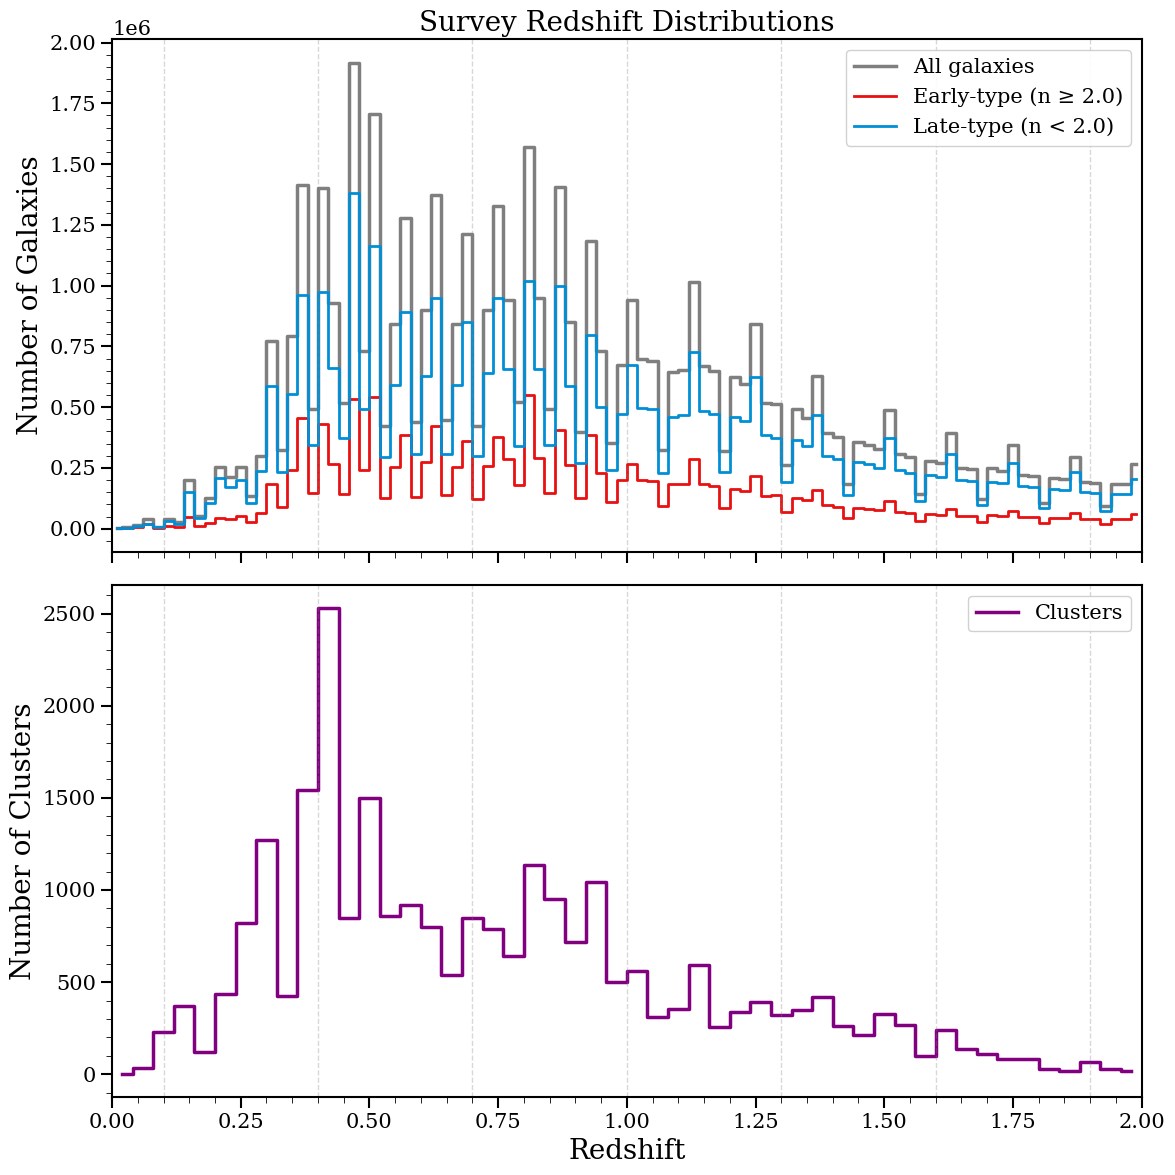

Saved: survey_properties_plots/nz_combined_overview.png


In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

# Histogram settings
z_range = (0.0, 2.0)
n_bins_gal = 100
n_bins_cl = 50

# === Top panel: Galaxies ===
bin_edges_gal = np.linspace(z_range[0], z_range[1], n_bins_gal + 1)
bin_centers_gal = 0.5 * (bin_edges_gal[1:] + bin_edges_gal[:-1])

# All galaxies
counts_all, _ = np.histogram(galaxy_z, bins=bin_edges_gal)
ax1.plot(bin_centers_gal, counts_all, color=COLOR_ALL, linewidth=2.5,
         drawstyle='steps-mid',
         label=f'All galaxies', alpha=0.5)

# Early-type
counts_early, _ = np.histogram(galaxy_z_early, bins=bin_edges_gal)
ax1.plot(bin_centers_gal, counts_early, color=COLOR_EARLY, linewidth=2,
         drawstyle='steps-mid',
         label=f'Early-type (n ≥ 2.0)')

# Late-type
counts_late, _ = np.histogram(galaxy_z_late, bins=bin_edges_gal)
ax1.plot(bin_centers_gal, counts_late, color=COLOR_LATE, linewidth=2,
         drawstyle='steps-mid',
         label=f'Late-type (n < 2.0)')

ax1.set_ylabel('Number of Galaxies')
ax1.set_title('Survey Redshift Distributions')
ax1.legend(loc='upper right', frameon=True, framealpha=0.9)
ax1.minorticks_on()

# === Bottom panel: Clusters ===
bin_edges_cl = np.linspace(z_range[0], z_range[1], n_bins_cl + 1)
bin_centers_cl = 0.5 * (bin_edges_cl[1:] + bin_edges_cl[:-1])

counts_clusters, _ = np.histogram(cluster_z, bins=bin_edges_cl)
ax2.plot(bin_centers_cl, counts_clusters, color=COLOR_CLUSTERS, linewidth=2.5,
         drawstyle='steps-mid',
         label=f'Clusters')

# Add vertical lines for tomographic bins
for z_edge in REDSHIFT_BINS:
    ax1.axvline(z_edge, color='gray', linestyle='--', alpha=0.3, linewidth=1)
    ax2.axvline(z_edge, color='gray', linestyle='--', alpha=0.3, linewidth=1)

ax2.set_xlabel('Redshift')
ax2.set_ylabel('Number of Clusters')
ax2.legend(loc='upper right', frameon=True, framealpha=0.9)
ax2.minorticks_on()
ax2.set_xlim(z_range)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'nz_combined_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {OUTPUT_DIR / 'nz_combined_overview.png'}")

## Summary Statistics

In [7]:
print("=" * 70)
print("SURVEY SUMMARY STATISTICS")
print("=" * 70)

print("\nCLUSTERS:")
print(f"  Total number: {len(cluster_z)}")
print(f"  Redshift range: {cluster_z.min():.3f} - {cluster_z.max():.3f}")
print(f"  Mean redshift: {cluster_z.mean():.3f}")
print(f"  Median redshift: {np.median(cluster_z):.3f}")

print("\nGALAXIES (ALL):")
print(f"  Total number: {len(galaxy_z)}")
print(f"  Redshift range: {galaxy_z.min():.3f} - {galaxy_z.max():.3f}")
print(f"  Mean redshift: {galaxy_z.mean():.3f}")
print(f"  Median redshift: {np.median(galaxy_z):.3f}")

print("\nGALAXIES (EARLY-TYPE):")
print(f"  Total number: {len(galaxy_z_early)} ({100*len(galaxy_z_early)/len(galaxies):.1f}%)")
print(f"  Redshift range: {galaxy_z_early.min():.3f} - {galaxy_z_early.max():.3f}")
print(f"  Mean redshift: {galaxy_z_early.mean():.3f}")
print(f"  Median redshift: {np.median(galaxy_z_early):.3f}")

print("\nGALAXIES (LATE-TYPE):")
print(f"  Total number: {len(galaxy_z_late)} ({100*len(galaxy_z_late)/len(galaxies):.1f}%)")
print(f"  Redshift range: {galaxy_z_late.min():.3f} - {galaxy_z_late.max():.3f}")
print(f"  Mean redshift: {galaxy_z_late.mean():.3f}")
print(f"  Median redshift: {np.median(galaxy_z_late):.3f}")

print("\nGALAXIES BY TOMOGRAPHIC BIN:")
for i in range(len(REDSHIFT_BINS) - 1):
    z_min, z_max = REDSHIFT_BINS[i], REDSHIFT_BINS[i + 1]
    mask = (galaxy_z >= z_min) & (galaxy_z < z_max)
    n_in_bin = mask.sum()
    print(f"  {z_min:.1f} < z < {z_max:.1f}: {n_in_bin} galaxies ({100*n_in_bin/len(galaxies):.1f}%)")

print("\n" + "=" * 70)

SURVEY SUMMARY STATISTICS

CLUSTERS:
  Total number: 25843
  Redshift range: 0.050 - 2.400
  Mean redshift: 0.740
  Median redshift: 0.660

GALAXIES (ALL):
  Total number: 62343553
  Redshift range: 0.010 - 6.000
  Mean redshift: 1.228
  Median redshift: 0.940

GALAXIES (EARLY-TYPE):
  Total number: 17429571 (28.0%)
  Redshift range: 0.010 - 6.000
  Mean redshift: 1.221
  Median redshift: 0.890

GALAXIES (LATE-TYPE):
  Total number: 44913982 (72.0%)
  Redshift range: 0.010 - 6.000
  Mean redshift: 1.231
  Median redshift: 0.960

GALAXIES BY TOMOGRAPHIC BIN:
  0.1 < z < 0.4: 5400334 galaxies (8.7%)
  0.4 < z < 0.7: 14552485 galaxies (23.3%)
  0.7 < z < 1.0: 13121073 galaxies (21.0%)
  1.0 < z < 1.3: 9440565 galaxies (15.1%)
  1.3 < z < 1.6: 5594432 galaxies (9.0%)
  1.6 < z < 1.9: 3470012 galaxies (5.6%)

